In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

# Task 1

Task 1: Discrete Pareto Analysis
Total alternatives: 15
Pareto-optimal alternatives: 4

Pareto-optimal alternatives (cost, quality):
P1: (12.48, 84.30)
P2: (35.86, 87.59)
P3: (46.69, 90.69)
P4: (79.91, 93.08)

Plot saved as 'task1_pareto.png'


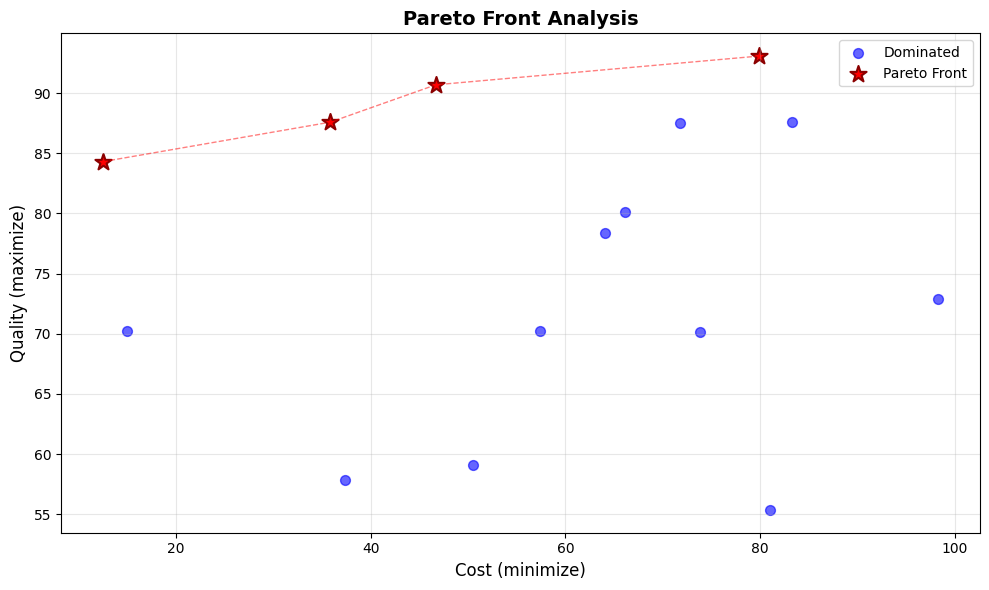

In [ ]:
np.random.seed(40)
alternatives = np.column_stack([
    np.random.uniform(10, 100, 15),  # Cost (minimize)
    np.random.uniform(50, 95, 15)    # Quality (maximize)
])

def is_pareto_optimal(costs):
    """
    Identify Pareto-optimal points.
    For each point, check if any other point dominates it.
    A point dominates another if it's better in at least one objective and not worse in others.
    """
    n_points = costs.shape[0]
    is_efficient = np.ones(n_points, dtype=bool)
    
    for i in range(n_points):
        if is_efficient[i]:
            # Check if point i is dominated by any other efficient point
            # For minimization: costs[j] < costs[i] is better
            # We need: (cost[j] <= cost[i] AND quality[j] <= quality[i]) AND at least one strict inequality
            # Since we negated quality, both columns are for minimization
            
            # Point j dominates point i if:
            # costs[j, 0] <= costs[i, 0] AND costs[j, 1] <= costs[i, 1] AND at least one strict inequality
            is_dominated = np.all(costs <= costs[i], axis=1) & np.any(costs < costs[i], axis=1)
            is_dominated[i] = False  # A point doesn't dominate itself
            
            if np.any(is_dominated):
                is_efficient[i] = False
    
    return is_efficient

# Prepare cost for minimization and quality for maximization
# Negate quality so both objectives are minimization
costs_for_pareto = np.column_stack([alternatives[:, 0], -alternatives[:, 1]])
pareto_mask = is_pareto_optimal(costs_for_pareto)
pareto_front = alternatives[pareto_mask]

# Sort pareto front by cost for better visualization
sort_idx = np.argsort(pareto_front[:, 0])
pareto_front_sorted = pareto_front[sort_idx]

print("Task 1: Discrete Pareto Analysis")
print(f"Total alternatives: {len(alternatives)}")
print(f"Pareto-optimal alternatives: {pareto_mask.sum()}")
print("\nPareto-optimal alternatives (cost, quality):")
for i, (cost, quality) in enumerate(pareto_front_sorted, 1):
    print(f"P{i}: ({cost:.2f}, {quality:.2f})")

# Create visualization
plt.figure(figsize=(10, 6))
plt.scatter(alternatives[~pareto_mask, 0], alternatives[~pareto_mask, 1],
            c='blue', label='Dominated', alpha=0.6, s=50)
plt.scatter(pareto_front[:, 0], pareto_front[:, 1],
            c='red', s=150, label='Pareto Front', marker='*', edgecolors='darkred', linewidths=1.5)

# Connect Pareto front points with a line
plt.plot(pareto_front_sorted[:, 0], pareto_front_sorted[:, 1], 
         'r--', alpha=0.5, linewidth=1)

plt.xlabel('Cost (minimize)', fontsize=12)
plt.ylabel('Quality (maximize)', fontsize=12)
plt.title('Pareto Front Analysis', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Task 2

Task 2: Weighting Method Analysis
Solutions found: 21
f1 range: [0.00, 33.00]
f2 range: [0.00, 29.00]


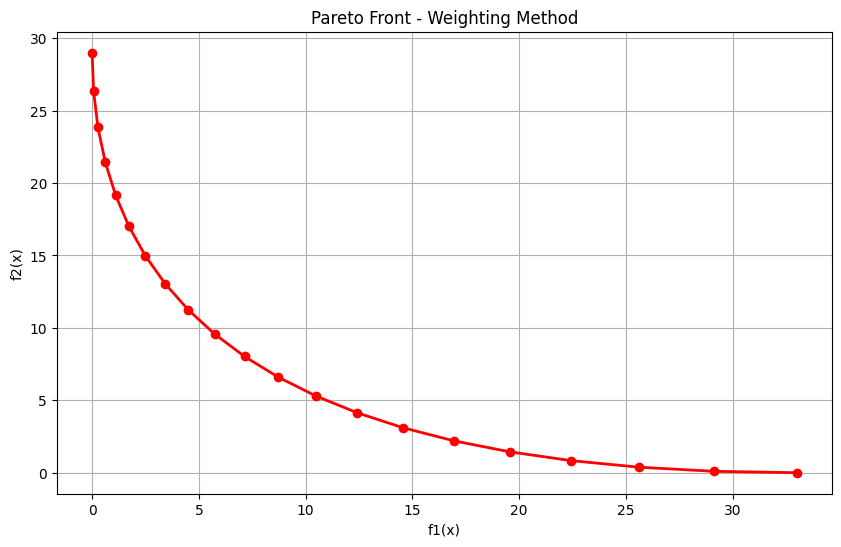

In [ ]:
# Task 2: Weighting Method for Continuous Problem
def f1(x):
    return (x[0] - 2)**2 + 2*(x[1] - 3)**2

def f2(x):
    return (x[0] + 3)**2 + (x[1] - 1)**2

def weighted_objective(x, w1):
    return w1 * f1(x) + (1 - w1) * f2(x)

# Generate Pareto front using weighting method
weights = np.arange(0, 1.05, 0.05)
pareto_solutions = []

for w1 in weights:
    result = minimize(lambda x: weighted_objective(x, w1), 
                     x0=[0, 0], bounds=[(-5, 5), (-5, 5)])
    if result.success:
        x_opt = result.x
        pareto_solutions.append([f1(x_opt), f2(x_opt)])

pareto_solutions = np.array(pareto_solutions)

print("Task 2: Weighting Method Analysis")
print(f"Solutions found: {len(pareto_solutions)}")
print(f"f1 range: [{pareto_solutions[:, 0].min():.2f}, {pareto_solutions[:, 0].max():.2f}]")
print(f"f2 range: [{pareto_solutions[:, 1].min():.2f}, {pareto_solutions[:, 1].max():.2f}]")

plt.figure(figsize=(10, 6))
plt.plot(pareto_solutions[:, 0], pareto_solutions[:, 1], 'ro-', linewidth=2, markersize=6)
plt.xlabel('f1(x)')
plt.ylabel('f2(x)')
plt.title('Pareto Front - Weighting Method')
plt.grid(True)
plt.show()


# Task 3

Task 3: Epsilon-Constraint Method Analysis
Solutions found: 29
f1 range: [0.41, 2.85]
f2 range: [1.00, 6.30]
Active constraints (f2 >= 0.95*epsilon): 12/29


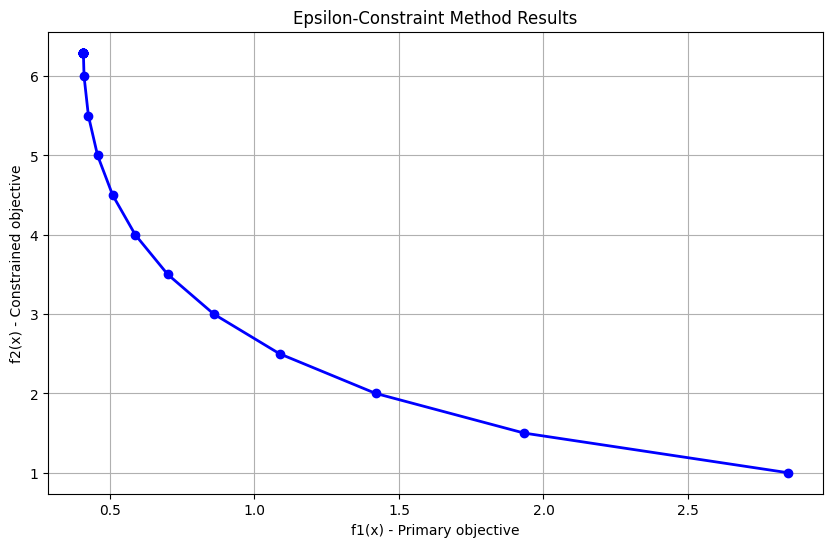

In [ ]:
# Task 3: Epsilon-Constraint Method
def f1(x):
    return x[0]**2 + x[1]**2 + np.sin(2*x[0]) + np.cos(x[1])

def f2(x):
    return (x[0] - 1)**2 + (x[1] - 2)**2 + 0.5*x[0]*x[1]

# Epsilon-constraint method
epsilons = np.arange(1, 15.5, 0.5)
solutions = []

for eps in epsilons:
    constraint = {'type': 'ineq', 'fun': lambda x, e=eps: e - f2(x)}
    result = minimize(f1, x0=[0, 0], bounds=[(-3, 3), (-3, 3)], 
                     constraints=constraint, method='SLSQP')
    if result.success:
        x_opt = result.x
        f1_val = f1(x_opt)
        f2_val = f2(x_opt)
        solutions.append([f1_val, f2_val, eps])

solutions = np.array(solutions)
active_constraints = np.sum(solutions[:, 1] >= 0.95 * solutions[:, 2])

print("Task 3: Epsilon-Constraint Method Analysis")
print(f"Solutions found: {len(solutions)}")
print(f"f1 range: [{solutions[:, 0].min():.2f}, {solutions[:, 0].max():.2f}]")
print(f"f2 range: [{solutions[:, 1].min():.2f}, {solutions[:, 1].max():.2f}]")
print(f"Active constraints (f2 >= 0.95*epsilon): {active_constraints}/{len(solutions)}")

plt.figure(figsize=(10, 6))
plt.plot(solutions[:, 0], solutions[:, 1], 'bo-', linewidth=2, markersize=6)
plt.xlabel('f1(x) - Primary objective')
plt.ylabel('f2(x) - Constrained objective')
plt.title('Epsilon-Constraint Method Results')
plt.grid(True)
plt.show()